In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
filepath = "../data/raw/all_organisms_filtered_without_M.musculus_KIDNEY.parquet"

In [20]:
df = pd.read_parquet(filepath)

In [21]:
integrated_df = df.query("is_integrated")

In [40]:
human_df = integrated_df.query("organism_name == 'H.sapiens'")

In [41]:
organ_corr_df = human_df.pivot(
    columns="sample_organ",
    values="abundance")

In [43]:
organ_corr_df.corr()

sample_organ,ADRENAL_GLAND,BRAIN,CEREBRAL_CORTEX,COLON,ESOPHAGUS,FALLOPIAN_TUBE,FEMALE_GONAD,FRONTAL_CORTEX,GALLBLADDER,HEART,...,SKIN,SPLEEN,STOMACH,TESTIS,THYROID_GLAND,TONSIL,URINARY_BLADDER,URINE,UTERUS,WHOLE_ORGANISM
sample_organ,,,,,,,,,,,,,,,,,,,,,
ADRENAL_GLAND,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BRAIN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CEREBRAL_CORTEX,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COLON,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESOPHAGUS,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FALLOPIAN_TUBE,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FEMALE_GONAD,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FRONTAL_CORTEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GALLBLADDER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
whole_organism_df = integrated_df.query("sample_organ == 'WHOLE_ORGANISM'")

In [30]:
organism_pivot_df = whole_organism_df.pivot_table(
    columns="organism_name",
    values="abundance",
    aggfunc=np.mean
)

/tmp/ipykernel_524882/707127876.py:1: FutureWarning: The provided callable <function mean at 0x7fdbe818c720> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  organism_pivot_df = whole_organism_df.pivot_table(


In [32]:
organism_pivot_df

organism_name,A.ferrooxidans,A.mellifera,A.thaliana,B.subtilis,B.taurus,B.thetaiotaomicron VPI,Bpertussis Tohama I,C.elegans,C.jejuni,C.neoformans,...,S.cerevisiae,S.enterica,S.pombe,S.pyogenes M1GAS,S.scrofa,Scoelicolor A3(2),Swittichii RW1,T.brucei,T.cruzi,Tgondii
abundance,758.158226,283.928968,48.248203,249.125911,91.919759,429.556685,1002.985918,76.608021,1298.701039,413.736279,...,155.205945,381.6805,215.148697,822.372758,118.821623,289.186813,2227.160022,167.224263,220.85029,401.126504


/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/conda-envs/pmda-valentyn/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/conda-envs/pmda-valentyn/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


<Axes: xlabel='organism_name', ylabel='organism_name'>

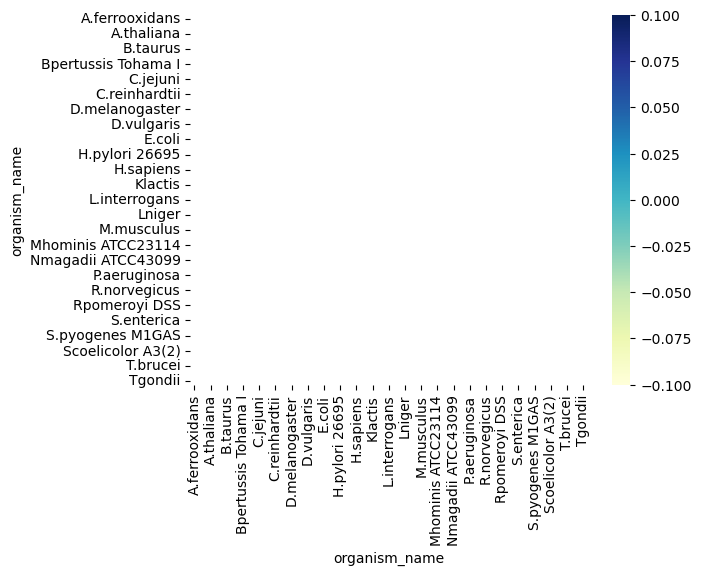

In [31]:
sns.heatmap(organism_pivot_df.corr(method="pearson"), cmap="YlGnBu")